# Customer Propensity Model - Online Retail Dataset

A binary classification model predicting which customers are likely to make a repeat purchase. Built using RFM features and logistic regression.

**Dateset**: UCI Online Retail
**Tools**: Python, Pandas, Scikit-learn
**Author**: Manuel "Chok" Capiendo

# Load Libaries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

print("libraries loaded")

libraries loaded


# Load Data

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
online_retail = fetch_ucirepo(id=352) 
  
df = online_retail.data.original.copy()

print("Data loaded")
print("Shape:", df.shape)

Data loaded
Shape: (541909, 8)


# Clean Data

In [3]:
# Drop the rows missing an ID
df = df.dropna(subset=['CustomerID'])

print('Current rows:', df.shape[0])

Current rows: 406829


In [4]:
# Change invoicedate from object to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [5]:
# Remove cancelled transactions
df = df[~df['InvoiceNo'].str.startswith('C')]

print('Current rows:', df.shape[0])

Current rows: 397924


# Split Data

In [6]:
#split into testing and training
train = df[df['InvoiceDate'] < '2011-07-01']
test = df[df['InvoiceDate'] >= '2011-07-01']

print("training rows:", train.shape[0])
print("testing rows:", test.shape[0])

training rows: 172648
testing rows: 225276


# RFM Features

In [7]:
# How many days from for recency
reference_date = pd.Timestamp('2011-07-01')

rfm = train.groupby('CustomerID').agg(
    # For each customer find the most recent purchase date and subtract from reference date and convert to # of days
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),

    # Check how many unique invoices each customer has
    Frequency=('InvoiceNo', 'nunique'),

    # Check the customers total spent
    Monetary=('UnitPrice', lambda x: (x * train.loc[x.index, 'Quantity']).sum())
).reset_index()

print(rfm.head())
print("RFM shape:", rfm.shape)

   CustomerID  Recency  Frequency  Monetary
0     12346.0      163          1  77183.60
1     12347.0       21          4   2205.95
2     12348.0       86          3   1487.24
3     12350.0      148          1    334.40
4     12352.0      100          5   1561.81
RFM shape: (2960, 4)


# Target Label

In [8]:
# Pick out who purchased inside the test period
purchased_in_test = test['CustomerID'].unique()

# Create new column and check if this customer is also in test list, save as int for 1 as true and 0 as false
rfm['Target'] = rfm['CustomerID'].isin(purchased_in_test).astype(int)

print('Customers who came back:', rfm['Target'].sum())
print('Customers who didnt:', (rfm['Target'] == 0).sum())

Customers who came back: 1988
Customers who didnt: 972


# Prep Features

In [9]:
# Set up features and targets
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Target']

# Scale the rfm features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train & Evaluate Model

In [10]:
# Split into train and test sets, 20% is test 80% train
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=67)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions of coming back
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.52      0.30      0.38       188
           1       0.73      0.87      0.79       404

    accuracy                           0.69       592
   macro avg       0.63      0.59      0.59       592
weighted avg       0.66      0.69      0.66       592

ROC AUC Score: 0.7264719823046134


# Propensity Scores

In [12]:
# Make new column to store score on all customers
rfm['PropensityScore'] = model.predict_proba(X_scaled)[:,1]

# Sort by highest propensity
top_prospects = rfm.sort_values('PropensityScore', ascending=False).head(10)

print(top_prospects[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'PropensityScore']].reset_index(drop=True))

   CustomerID  Recency  Frequency   Monetary  PropensityScore
0     12748.0        0        102   11557.04         1.000000
1     14911.0        0         78   48877.98         1.000000
2     13089.0        8         57   31687.92         1.000000
3     17841.0        0         56   14698.46         1.000000
4     14606.0        1         56    7718.04         1.000000
5     15311.0        1         49   37109.77         1.000000
6     12971.0        6         45    5215.64         1.000000
7     13798.0        3         36   24797.78         1.000000
8     16029.0        2         35   39745.86         0.999999
9     14646.0        2         32  136002.11         0.999999


# Visualize Propensity

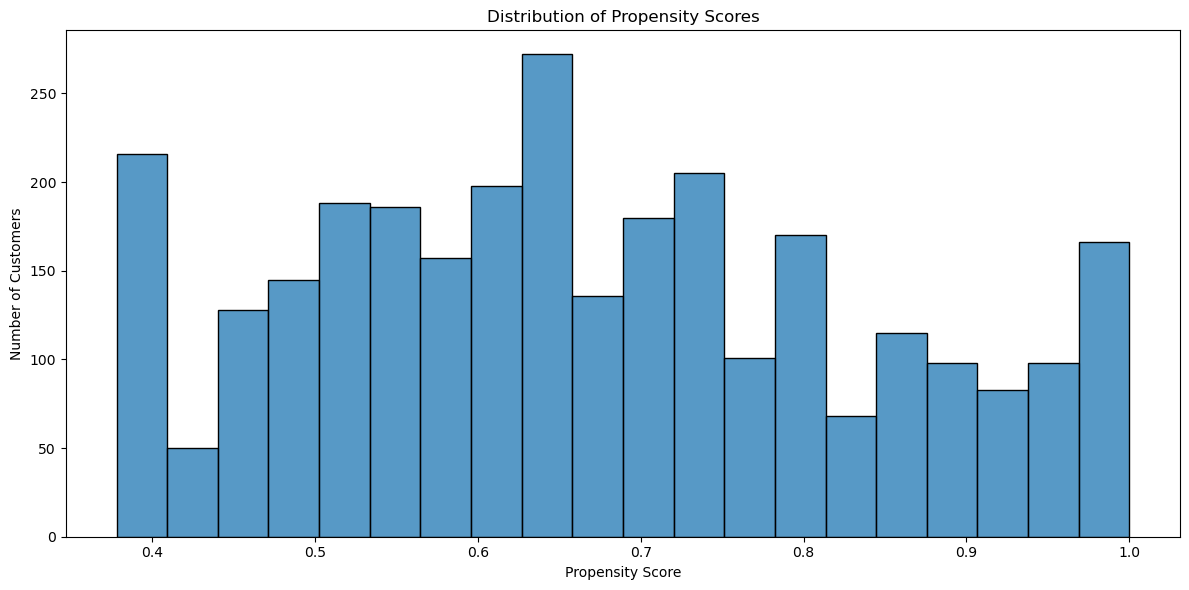

In [13]:
plt.figure(figsize=(12,6))
sns.histplot(rfm['PropensityScore'], bins=20)

plt.title('Distribution of Propensity Scores')
plt.xlabel('Propensity Score')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()